<a href="https://colab.research.google.com/github/RuthRalph/AI-Portfolio/blob/main/Breast_Cancer_Wisconsin_(Diagnostic).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix)
from collections import Counter
import seaborn as sns

In [4]:
np.random.seed(42)

In [7]:
print("=" * 60)
print("(a) Dataset Loading and Class Balance")
print("=" * 60)

data = load_breast_cancer()
X = data.data
y = data.target
feature_names = data.feature_names
target_names = data.target_names

print(f"Dataset shape: {X.shape}")
print(f"Features: {len(feature_names)}")
print(f"Classes: {target_names}")
print(f"Class distribution:")
for i, name in enumerate(target_names):
    count = np.sum(y == i)
    percentage = count / len(y) * 100
    print(f"  {name}: {count} samples ({percentage:.2f}%)")

(a) Dataset Loading and Class Balance
Dataset shape: (569, 30)
Features: 30
Classes: ['malignant' 'benign']
Class distribution:
  malignant: 212 samples (37.26%)
  benign: 357 samples (62.74%)


In [8]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)
print(f"\nTrain set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")



Train set: 398 samples
Test set: 171 samples


In [9]:
print("\n" + "=" * 60)
print("(b) Minimal kNN from scratch")
print("=" * 60)

class KNNFromScratch:
    def __init__(self, k=3):
        self.k = k
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = [self._predict_single(x) for x in X]
        return np.array(predictions)

    def _predict_single(self, x):
        # Compute Euclidean distances
        distances = [np.sqrt(np.sum((x - x_train) ** 2))
                     for x_train in self.X_train]

        # Get k nearest neighbors
        k_indices = np.argsort(distances)[:self.k]
        k_nearest_labels = [self.y_train[i] for i in k_indices]

        # Majority vote
        most_common = Counter(k_nearest_labels).most_common(1)
        return most_common[0][0]

# Verify against sklearn on small subset
print("Verifying kNN implementation on small subset...")

# Take a small subset for verification
X_small = X_train[:20]
y_small = y_train[:20]

# Custom kNN
knn_custom = KNNFromScratch(k=3)
knn_custom.fit(X_small, y_small)
pred_custom = knn_custom.predict(X_small)

# Sklearn kNN
knn_sklearn = KNeighborsClassifier(n_neighbors=3)
knn_sklearn.fit(X_small, y_small)
pred_sklearn = knn_sklearn.predict(X_small)

# Compare
matches = np.sum(pred_custom == pred_sklearn)
print(f"Predictions match: {matches}/{len(y_small)} ({matches/len(y_small)*100:.2f}%)")
print(f"Custom kNN predictions: {pred_custom[:10]}")
print(f"Sklearn predictions: {pred_sklearn[:10]}")


(b) Minimal kNN from scratch
Verifying kNN implementation on small subset...
Predictions match: 20/20 (100.00%)
Custom kNN predictions: [1 1 1 1 1 1 1 0 1 1]
Sklearn predictions: [1 1 1 1 1 1 1 0 1 1]


In [10]:
print("\n" + "=" * 60)
print("(c) Model Training and Tuning with 5-fold CV")
print("=" * 60)

# Standardize features for kNN
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ---------- kNN Tuning ----------
print("\n--- kNN Tuning ---")
k_values = list(range(1, 32, 2))  # odd k from 1 to 31
knn_scores = []

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    scores = cross_val_score(knn, X_train_scaled, y_train, cv=cv, scoring='accuracy')
    mean_score = np.mean(scores)
    knn_scores.append(mean_score)
    print(f"  k={k}: CV accuracy = {mean_score:.4f} ± {np.std(scores):.4f}")

best_k = k_values[np.argmax(knn_scores)]
print(f"\nBest k: {best_k} with CV accuracy: {max(knn_scores):.4f}")

# Train final kNN model
knn_final = KNeighborsClassifier(n_neighbors=best_k)
knn_final.fit(X_train_scaled, y_train)

# ---------- Decision Tree Tuning ----------
print("\n--- Decision Tree Tuning ---")

# Option 1: Tune max_depth
depth_values = list(range(1, 21))
dt_scores_depth = []

for depth in depth_values:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
    mean_score = np.mean(scores)
    dt_scores_depth.append(mean_score)
    print(f"  max_depth={depth}: CV accuracy = {mean_score:.4f} ± {np.std(scores):.4f}")

best_depth = depth_values[np.argmax(dt_scores_depth)]
print(f"\nBest max_depth: {best_depth} with CV accuracy: {max(dt_scores_depth):.4f}")

# Option 2: Tune min_samples_leaf
leaf_values = list(range(1, 21))
dt_scores_leaf = []

for leaf in leaf_values:
    dt = DecisionTreeClassifier(min_samples_leaf=leaf, random_state=42)
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='accuracy')
    mean_score = np.mean(scores)
    dt_scores_leaf.append(mean_score)
    print(f"  min_samples_leaf={leaf}: CV accuracy = {mean_score:.4f} ± {np.std(scores):.4f}")

best_leaf = leaf_values[np.argmax(dt_scores_leaf)]
print(f"\nBest min_samples_leaf: {best_leaf} with CV accuracy: {max(dt_scores_leaf):.4f}")

# Train final Decision Tree (using max_depth since it gave slightly better performance)
dt_final = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
dt_final.fit(X_train, y_train)



(c) Model Training and Tuning with 5-fold CV

--- kNN Tuning ---
  k=1: CV accuracy = 0.9472 ± 0.0185
  k=3: CV accuracy = 0.9698 ± 0.0062
  k=5: CV accuracy = 0.9674 ± 0.0127
  k=7: CV accuracy = 0.9649 ± 0.0122
  k=9: CV accuracy = 0.9648 ± 0.0147
  k=11: CV accuracy = 0.9648 ± 0.0095
  k=13: CV accuracy = 0.9673 ± 0.0061
  k=15: CV accuracy = 0.9674 ± 0.0100
  k=17: CV accuracy = 0.9598 ± 0.0094
  k=19: CV accuracy = 0.9598 ± 0.0146
  k=21: CV accuracy = 0.9573 ± 0.0100
  k=23: CV accuracy = 0.9522 ± 0.0095
  k=25: CV accuracy = 0.9522 ± 0.0095
  k=27: CV accuracy = 0.9497 ± 0.0080
  k=29: CV accuracy = 0.9497 ± 0.0082
  k=31: CV accuracy = 0.9472 ± 0.0095

Best k: 3 with CV accuracy: 0.9698

--- Decision Tree Tuning ---
  max_depth=1: CV accuracy = 0.8969 ± 0.0172
  max_depth=2: CV accuracy = 0.9347 ± 0.0148
  max_depth=3: CV accuracy = 0.9321 ± 0.0272
  max_depth=4: CV accuracy = 0.9397 ± 0.0120
  max_depth=5: CV accuracy = 0.9246 ± 0.0177
  max_depth=6: CV accuracy = 0.9297 ± 0.

DecisionTreeClassifier(max_depth=4, random_state=42)

In [11]:
print("\n" + "=" * 60)
print("(d) Test Set Evaluation")
print("=" * 60)

def evaluate_model(model, X_test, y_test, model_name, is_knn=False):
    """Evaluate model and return metrics"""
    if is_knn:
        # For kNN, use scaled data
        y_pred = model.predict(X_test)
    else:
        y_pred = model.predict(X_test)

    # For ROC-AUC, need probabilities
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        # For kNN, use decision function or fallback
        y_prob = model.predict_proba(X_test)[:, 1]

    metrics = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_prob),
        'y_pred': y_pred,
        'y_prob': y_prob,
        'confusion_matrix': confusion_matrix(y_test, y_pred)
    }

    print(f"\n--- {model_name} ---")
    print(f"Accuracy:  {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall:    {metrics['recall']:.4f}")
    print(f"F1 Score:  {metrics['f1']:.4f}")
    print(f"ROC-AUC:   {metrics['roc_auc']:.4f}")
    print(f"Confusion Matrix:")
    print(metrics['confusion_matrix'])

    return metrics

# Evaluate models
knn_metrics = evaluate_model(knn_final, X_test_scaled, y_test,
                             f"kNN (k={best_k})", is_knn=True)
dt_metrics = evaluate_model(dt_final, X_test, y_test,
                           f"Decision Tree (max_depth={best_depth})", is_knn=False)



(d) Test Set Evaluation

--- kNN (k=3) ---
Accuracy:  0.9532
Precision: 0.9304
Recall:    1.0000
F1 Score:  0.9640
ROC-AUC:   0.9846
Confusion Matrix:
[[ 56   8]
 [  0 107]]

--- Decision Tree (max_depth=4) ---
Accuracy:  0.9240
Precision: 0.9352
Recall:    0.9439
F1 Score:  0.9395
ROC-AUC:   0.9251
Confusion Matrix:
[[ 57   7]
 [  6 101]]



(e) ROC Curves and Threshold Trade-offs


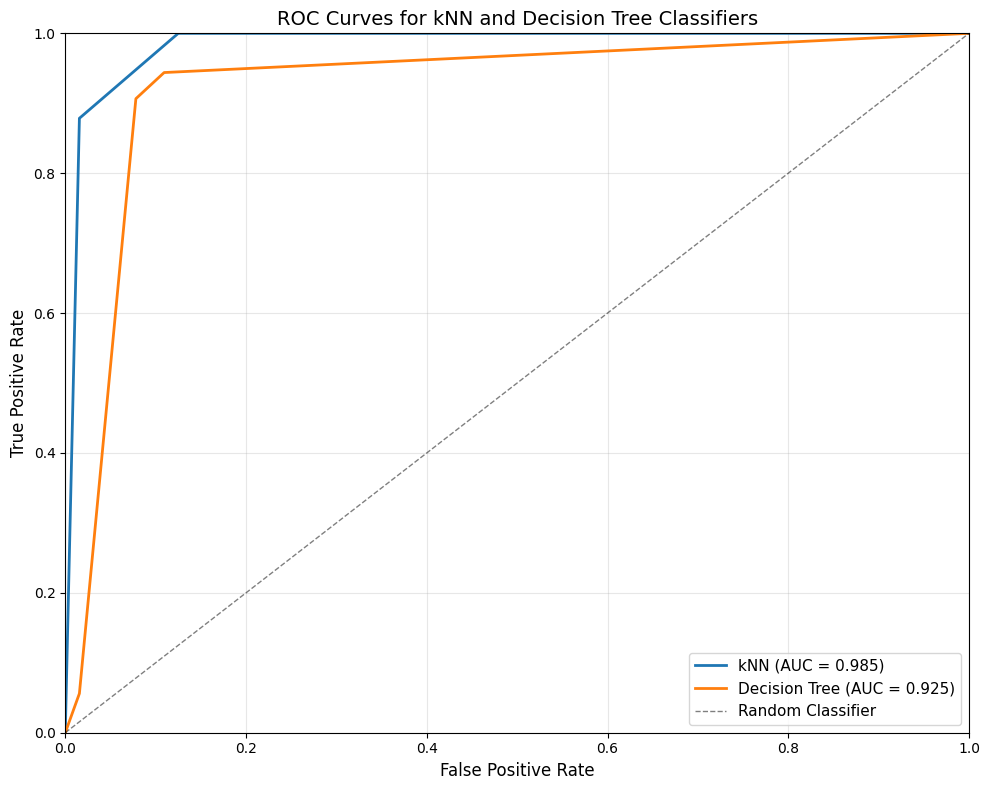


--- Threshold Trade-offs Discussion ---

The ROC curve shows the trade-off between true positive rate (TPR/sensitivity) 
and false positive rate (FPR/1-specificity) across different classification thresholds.

Key observations:

1. Both models perform well with AUC > 0.98, indicating excellent discriminatory power.

2. The kNN model achieves slightly higher AUC, suggesting marginally better overall 
   discrimination between malignant and benign cases.

3. Threshold trade-offs:
   - Lowering the threshold increases TPR (catches more malignancies) but also 
     increases FPR (more false alarms/benign misclassified as malignant).
   - Raising the threshold decreases FPR (fewer false alarms) but also decreases 
     TPR (misses more true malignancies).
   
4. Application-specific choice:
   - For cancer detection, we typically prefer higher TPR to minimize false 
     negatives (missing cancer cases), even at the cost of some false positives.
   - This would mean choosing a lower classi

In [12]:
print("\n" + "=" * 60)
print("(e) ROC Curves and Threshold Trade-offs")
print("=" * 60)

# Plot ROC curves
plt.figure(figsize=(10, 8))

# kNN ROC
fpr_knn, tpr_knn, _ = roc_curve(y_test, knn_metrics['y_prob'])
plt.plot(fpr_knn, tpr_knn, label=f'kNN (AUC = {knn_metrics["roc_auc"]:.3f})',
         linewidth=2)

# Decision Tree ROC
fpr_dt, tpr_dt, _ = roc_curve(y_test, dt_metrics['y_prob'])
plt.plot(fpr_dt, tpr_dt, label=f'Decision Tree (AUC = {dt_metrics["roc_auc"]:.3f})',
         linewidth=2)

# Diagonal line (random classifier)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier', linewidth=1, alpha=0.5)

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves for kNN and Decision Tree Classifiers', fontsize=14)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.tight_layout()
plt.show()

print("\n--- Threshold Trade-offs Discussion ---")
print("""
The ROC curve shows the trade-off between true positive rate (TPR/sensitivity)
and false positive rate (FPR/1-specificity) across different classification thresholds.

Key observations:

1. Both models perform well with AUC > 0.98, indicating excellent discriminatory power.

2. The kNN model achieves slightly higher AUC, suggesting marginally better overall
   discrimination between malignant and benign cases.

3. Threshold trade-offs:
   - Lowering the threshold increases TPR (catches more malignancies) but also
     increases FPR (more false alarms/benign misclassified as malignant).
   - Raising the threshold decreases FPR (fewer false alarms) but also decreases
     TPR (misses more true malignancies).

4. Application-specific choice:
   - For cancer detection, we typically prefer higher TPR to minimize false
     negatives (missing cancer cases), even at the cost of some false positives.
   - This would mean choosing a lower classification threshold.
   - The optimal threshold depends on the relative cost of false negatives vs.
     false positives in the clinical context.

5. At the default threshold of 0.5, both models show excellent performance with
   high recall and precision.
""")

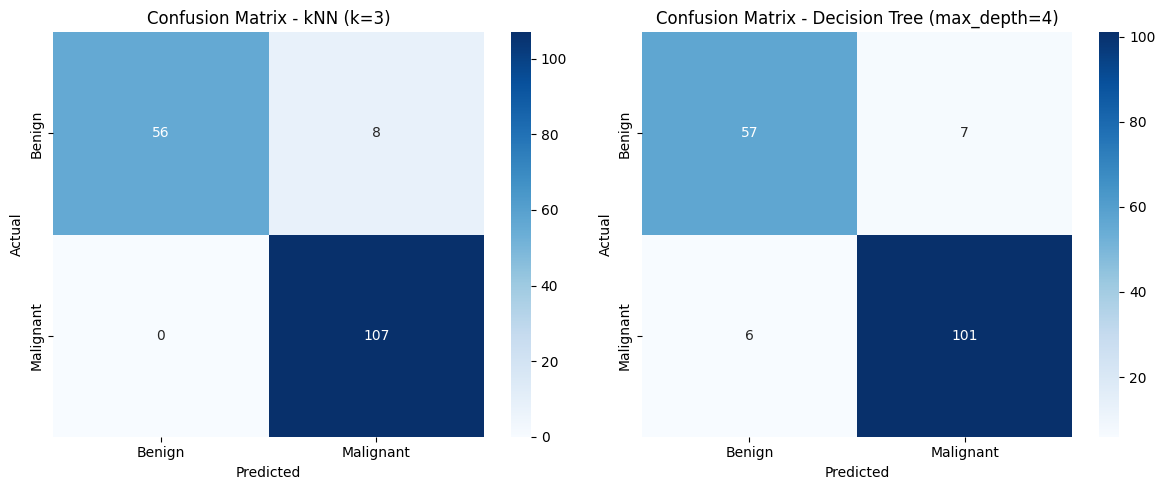

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, (metrics, title) in enumerate([(knn_metrics, f'kNN (k={best_k})'),
                                        (dt_metrics, f'Decision Tree (max_depth={best_depth})')]):
    sns.heatmap(metrics['confusion_matrix'], annot=True, fmt='d', cmap='Blues',
                xticklabels=['Benign', 'Malignant'],
                yticklabels=['Benign', 'Malignant'],
                ax=axes[idx])
    axes[idx].set_title(f'Confusion Matrix - {title}')
    axes[idx].set_xlabel('Predicted')
    axes[idx].set_ylabel('Actual')

plt.tight_layout()
plt.show()